# FIT5226 Project Stage 1 — Q-Learning

## Task: Pick up item at A, deliver to B on a 5×5 grid

In [464]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Reward Structure

| Event | Reward |
|---|---|
| Each step | -1 (encourages shortest path) |
| Pick up item at A | +20 (subgoal reward) |
| Deliver item to B | +100 (main goal) |
| Walk into wall | -1 (stay in place, normal step cost) |

## 2. Environment

In [465]:
# 8 actions: N, NE, E, SE, S, SW, W, NW
ACTIONS = [(0,-1), (1,-1), (1,0), (1,1), (0,1), (-1,1), (-1,0), (-1,-1)]
ACTION_NAMES = ['N','NE','E','SE','S','SW','W','NW']
N_ACTIONS = 8

In [466]:
class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.B = (size-1, size-1)       # fixed delivery location
        self.agent = None
        self.A = None
        self.has_item = False
    
    def reset(self):
        self.agent = (np.random.randint(self.size), np.random.randint(self.size))
        self.A = (np.random.randint(self.size), np.random.randint(self.size))
        self.has_item = False
        return self.get_state()
    
    def get_state(self):
        """State = (agent_x, agent_y, pickup_x, pickup_y, has_item)"""
        return (self.agent[0], self.agent[1], self.A[0], self.A[1], self.has_item)
    
    def step(self, action):
        if self.agent == self.A and not self.has_item:
            self.has_item = True
            if self.agent == self.B:
                return self.get_state(), 120, True
            return self.get_state(), 20, False
        
        dx, dy = ACTIONS[action]
        nx, ny = self.agent[0] + dx, self.agent[1] + dy
    
        # boundary check
        if 0 <= nx < self.size and 0 <= ny < self.size:
            self.agent = (nx, ny)
    
        # check pickup
        # handle condition where the spawn position of A and agent are in the same position. Also handles when 
        # agent A and B are spawned in thhe same position as well.
        if self.agent == self.A and not self.has_item:
            self.has_item = True
            if self.agent == self.B:
                return self.get_state(), 120, True
            return self.get_state(), 20, False
    
        # check delivery
        if self.agent == self.B and self.has_item:
            return self.get_state(), 100, True
    
        # normal step
        return self.get_state(), -1, False

In [467]:
# sanity check
env = GridWorld(size=5)
S = env.reset()
print(f"Initial state: {S}")
print(f"Agent at: {env.agent}, Pickup at: {env.A}, Deliver to: {env.B}")

Initial state: (0, 0, 2, 3, False)
Agent at: (0, 0), Pickup at: (2, 3), Deliver to: (4, 4)


## 3. Q-Learning Implementation

dictionary-based Q-table, epsilon-greedy policy, Q-update.

In [468]:
# Q-table as dictionary: state -> array of 8 Q-values
Q = {}

def get_q(state):
    """Return Q-values for a state, initialise to zeros if unseen."""
    if state not in Q:
        Q[state] = np.zeros(N_ACTIONS)
    return Q[state]

In [469]:
# Policy: epsilon-greedy
eps = 0.1

def policy(S):
    """Choose action using epsilon-greedy."""
    """ rand random picks a number between 0 to 1 and if the random number bigger than 0.1 then choose action from teh q table"""
    if np.random.random() > eps:
        return np.argmax(get_q(S))   # exploit: best known action
    else:
        return np.random.randint(N_ACTIONS)  # explore: random action

In [470]:
# Hyperparameters
gamma = 0.90   # discount factor
alpha = 0.1    # learning rate
episodes = 20000
max_steps = 200  # prevent infinite wandering

In [471]:
# Training loop
rewards_history = []
steps_history = []

for ep in range(episodes):
    S = env.reset()
    total_reward = 0
    
    for step in range(max_steps):
        # 1. Choose action
        A = policy(S)
        
        # 2. Take action, observe result
        S1, R, done = env.step(A)
        
        # 3. Q-learning update
        #    Q(S,A) = (1-alpha)*Q(S,A) + alpha*(R + gamma*max(Q(S1)))
        Q_old = get_q(S)[A]
        Q_future = np.max(get_q(S1))
        get_q(S)[A] = (1 - alpha) * Q_old + alpha * (R + gamma * Q_future)
        
        # 4. Move to next state
        S = S1
        total_reward += R
        
        if done:
            break
    
    rewards_history.append(total_reward)
    steps_history.append(step + 1)

print(f"Training complete. Q-table has {len(Q)} entries.")

Training complete. Q-table has 1186 entries.


## 4. Training and Testing

In [472]:
# Test: run 1000 episodes with pure greedy (eps=0)
test_steps = []
test_success = 0

for _ in range(1000):
    S = env.reset()
    for step in range(200):
        A = np.argmax(get_q(S))  # pure greedy, no exploration
        S, R, done = env.step(A)
        if done:
            test_steps.append(step + 1)
            test_success += 1
            break

print(f"Success rate: {test_success}/1000 ({test_success/10:.1f}%)")
print(f"Avg steps to complete: {np.mean(test_steps):.1f}")
print(f"Max steps: {np.max(test_steps)}")
print(f"Solved in ≤10 steps: {sum(1 for s in test_steps if s <= 10)}/{test_success}")

Success rate: 1000/1000 (100.0%)
Avg steps to complete: 5.8
Max steps: 10
Solved in ≤10 steps: 1000/1000


### Testing Edge Cases

In [473]:
def test_edge_cases(env, Q):
    cases = [
        # (agent_x, agent_y, pickup_x, pickup_y, description)
        
        # Agent starts on pickup (immediate pickup)
        (2, 2, 2, 2, "Agent and A both at center"),
        (0, 0, 0, 0, "Agent and A both at top-left"),
        (3, 1, 3, 1, "Agent and A both at (3,1)"),
        
        # Agent starts on B
        (4, 4, 2, 2, "Agent starts on B, A at center"),
        (4, 4, 0, 0, "Agent starts on B, A at top-left"),
        
        # A is at B
        (0, 0, 4, 4, "A is at B, agent at top-left"),
        (2, 2, 4, 4, "A is at B, agent at center"),
        
        # All three overlap
        (4, 4, 4, 4, "Agent, A, and B all at (4,4)"),
    ]

    for ax, ay, px, py, desc in cases:
        env.agent = (ax, ay)
        env.A = (px, py)
        env.has_item = False

        # handle starting on pickup
        # if env.agent == env.A:
        #     env.has_item = True

        S = env.get_state()
        done = False

        for step in range(200):
            A = np.argmax(get_q(S))
            S, R, done = env.step(A)
            if done:
                break

        status = f"✅ {step+1} steps" if done else "❌ FAILED"
        print(f"{status} | {desc} | Agent=({ax},{ay}) A=({px},{py})")

test_edge_cases(env, Q)

✅ 4 steps | Agent and A both at center | Agent=(2,2) A=(2,2)
✅ 6 steps | Agent and A both at top-left | Agent=(0,0) A=(0,0)
✅ 4 steps | Agent and A both at (3,1) | Agent=(3,1) A=(3,1)
✅ 6 steps | Agent starts on B, A at center | Agent=(4,4) A=(2,2)
✅ 10 steps | Agent starts on B, A at top-left | Agent=(4,4) A=(0,0)
✅ 5 steps | A is at B, agent at top-left | Agent=(0,0) A=(4,4)
✅ 2 steps | A is at B, agent at center | Agent=(2,2) A=(4,4)
✅ 1 steps | Agent, A, and B all at (4,4) | Agent=(4,4) A=(4,4)


## 5. Documentation & Metrics

**Test procedure:**  
After training, we run 1000 test episodes using a pure greedy policy (always pick the best Q-value, no exploration). We measure:

1. **Success rate** — percentage of episodes where delivery is completed  
2. **Average steps** — mean number of steps to complete the task  
3. **≤10 step rate** — percentage of episodes solved in 10 steps or fewer  

Target Specification(according to assignment instruction)
100% of scenarios solved in ≤10 steps within 20,000 training episodes.

## 6. Visualisation

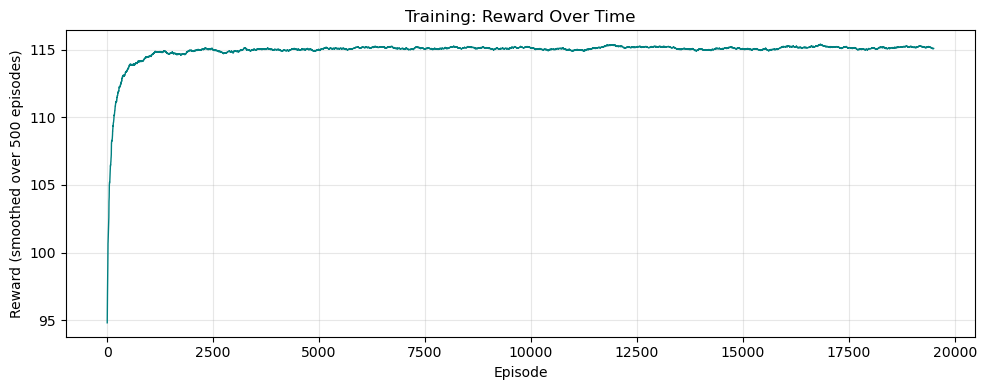

In [474]:
# Plot 1: Reward over training episodes (smoothed)
window = 500
smoothed_rewards = np.convolve(rewards_history, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed_rewards, color='teal', linewidth=1)
plt.xlabel('Episode')
plt.ylabel(f'Reward (smoothed over {window} episodes)')
plt.title('Training: Reward Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

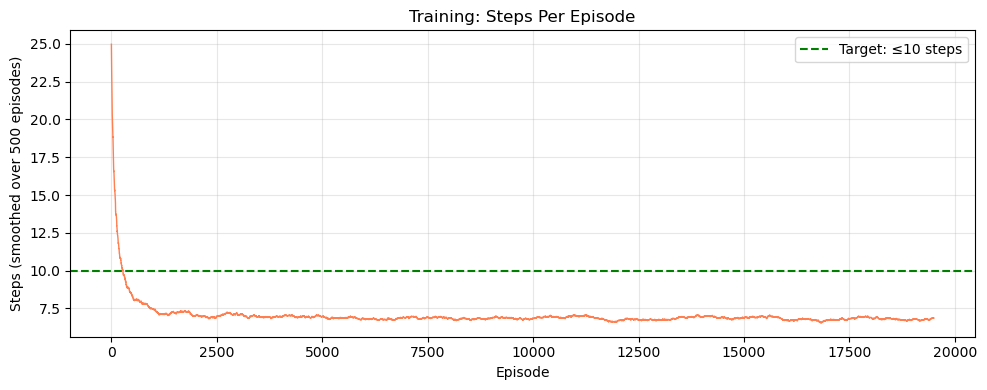

In [475]:
# Plot 2: Steps per episode over training (smoothed)
smoothed_steps = np.convolve(steps_history, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smoothed_steps, color='coral', linewidth=1)
plt.axhline(y=10, color='green', linestyle='--', label='Target: ≤10 steps')
plt.xlabel('Episode')
plt.ylabel(f'Steps (smoothed over {window} episodes)')
plt.title('Training: Steps Per Episode')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Run 1 ---


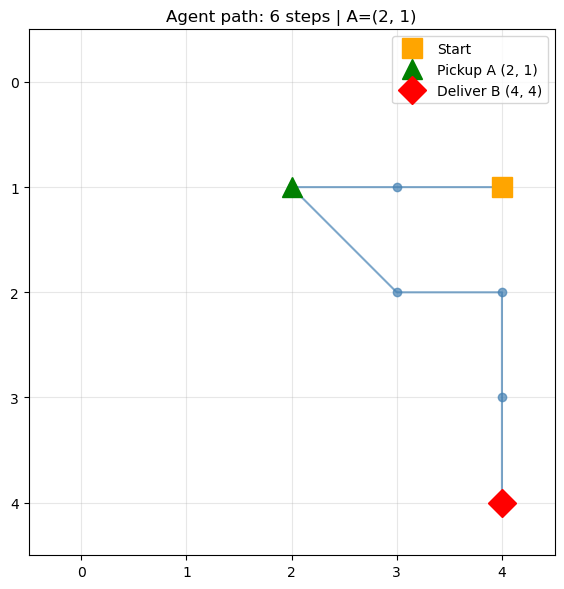

--- Run 2 ---


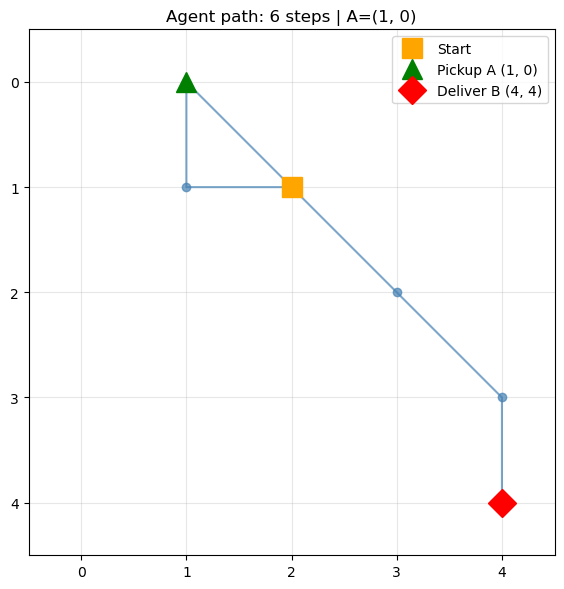

--- Run 3 ---


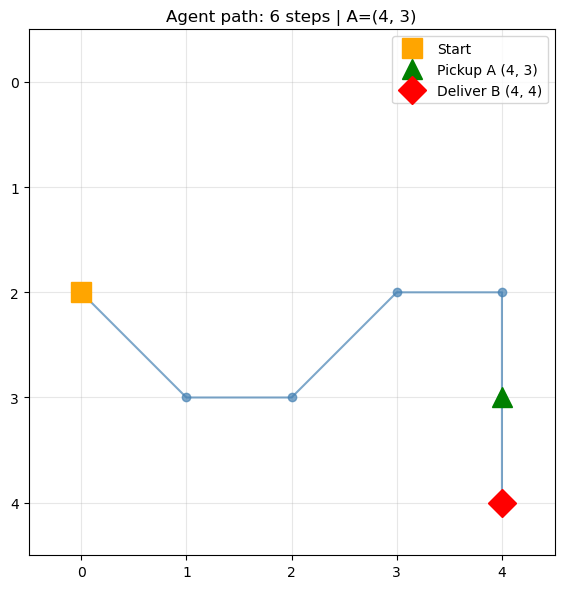

In [476]:
# Plot 3: Visualise a single test episode on the grid
def visualise_episode():
    S = env.reset()
    path = [env.agent]
    pickup_loc = env.A
    
    for _ in range(50):
        A = np.argmax(get_q(S))
        S, R, done = env.step(A)
        path.append(env.agent)
        if done:
            break
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(env.size - 0.5, -0.5)  # flip y so (0,0) is top-left
    ax.set_xticks(range(env.size))
    ax.set_yticks(range(env.size))
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # Draw path
    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    ax.plot(xs, ys, 'o-', color='steelblue', markersize=6, linewidth=1.5, alpha=0.7)
    
    # Mark start, pickup, delivery
    ax.plot(path[0][0], path[0][1], 's', color='orange', markersize=14, label='Start')
    ax.plot(pickup_loc[0], pickup_loc[1], '^', color='green', markersize=14, label=f'Pickup A {pickup_loc}')
    ax.plot(env.B[0], env.B[1], 'D', color='red', markersize=14, label=f'Deliver B {env.B}')
    
    ax.set_title(f'Agent path: {len(path)-1} steps | A={pickup_loc}')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Show 3 example runs
for i in range(3):
    print(f"--- Run {i+1} ---")
    visualise_episode()